### 第20章 支持向量机
- 支持向量机(Support Vector Machine, SVM)是一种二分类模型，目标是寻找一个超平面对样本数据进行分割，分割的原则是确保分类最优化(类别之间的间隔最大)
- 在已有数据中，找到离分类器最近的点，确保它们离分类器尽可能地远
- 离分类器最远的点称为支持向量(Support Vector)。离分类器最近的点到分类器距离和（两个异类支持向量到分类器的距离和）称为间隔(Margin)
- 一般情况下，把能够被一条直线（更一般的情况，是一条超平面）分割的数据称为线性可分的数据，所以超平面是线性分类器

#### SVM 分类流程
1. 生成分类器模型: `model = cv2.ml.SVM_create()`
2. 训练分类器: `训练结果 = model.train(训练数据, 训练数据排列格式, 训练数据的标签)`
3. 使用分类器完成分类: `(返回值, 返回结果) = model.predict(待分类数据)`

data.shape: (40, 2)
test: [[99. 94.]
 [94. 99.]]
p1 = 0.0  
 p2 = [[1.]
 [1.]]


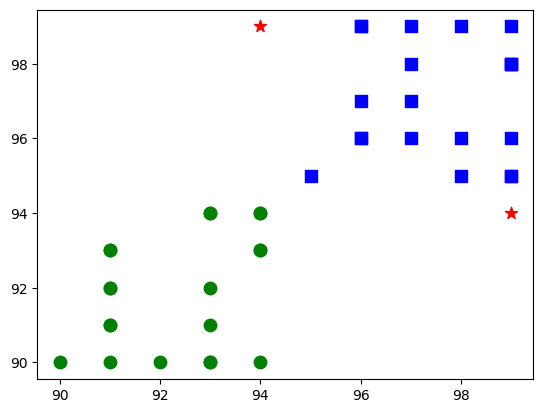

In [14]:
# ==============0.导入库=====================
import cv2
import numpy as np
import matplotlib.pyplot as plt

# =========== 1. 样本数据与数据标签处理=================
# 1.1 生成模拟样本数据
a = np.random.randint(90, 95, (20, 2)).astype(np.float32)
b = np.random.randint(95, 100, (20, 2)).astype(np.float32)
data = np.vstack((a, b))
data = np.array(data, dtype="float32")
# 1.2 为样本数据贴标签
aLabel = np.zeros((20, 1))
bLabel = np.ones((20, 1))
label = np.vstack((aLabel, bLabel))
label = np.array(label, dtype="int32")
print("data.shape:", data.shape)

# =============== 2. 待分类数据处理=================
# test = np.vstack([[98, 90], [90, 99]])  # 评级：0-A级 1-B级
test = np.random.randint(90, 100, (2, 2)).astype(np.float32)
test = np.array(test, dtype="float32")
print("test:", test)

# =============== 3. SVM分类器=====================
svm = cv2.ml.SVM_create()
svm.train(data, cv2.ml.ROW_SAMPLE, label)
(p1, p2) = svm.predict(test)
# p1：返回码，通常是 0（表示预测成功）。
# p2：预测结果数组，包含每个测试样本的预测类别标签（0 或 1）
print("p1 =", p1, " \n p2 =", p2)
# ============ 4. 显示分类结果分类==================
plt.scatter(a[:, 0], a[:, 1], s=80, c="g", marker="o")
plt.scatter(b[:, 0], b[:, 1], s=80, c="b", marker="s")
plt.scatter(test[:, 0], test[:, 1], s=80, c="r", marker="*")
plt.show()

#### 手写数字识别

In [ ]:
import cv2
import numpy as np


# =============抗扭斜函数=================
def deskew(img):
    m = cv2.moments(img)  # 计算图像的矩（moments），检测倾斜程度
    if abs(m["mu02"]) < 1e-2:
        return img.copy()    # 如果倾斜度很小，就直接返回原图
    skew = m["mu11"] / m["mu02"]
    s = 20
    M = np.float32([[1, skew, -0.5 * s * skew], [0, 1, 0]]) # 仿射变换矩阵，用于纠正倾斜度
    affine_flags = cv2.WARP_INVERSE_MAP | cv2.INTER_LINEAR  # 仿射变换标志位
    size = (20, 20)  # 每个数字的图像的尺寸
    img = cv2.warpAffine(img, M, size, flags=affine_flags)  # 纠正倾斜度
    return img


# =============HOG函数=================
def hog(img):
    gx = cv2.Sobel(img, cv2.CV_32F, 1, 0)   # 计算水平梯度
    gy = cv2.Sobel(img, cv2.CV_32F, 0, 1)   # 计算垂直梯度
    mag, ang = cv2.cartToPolar(gx, gy)      # 计算梯度幅值和角度
    bins = np.int32(16 * ang / (2 * np.pi)) # 将角度转换为16个区间，便于统计直方图
    # 将图像分为4个部分，分别统计每个部分的直方图
    bin_cells = bins[:10, :10], bins[10:, :10], bins[:10, 10:], bins[10:, 10:]  
    mag_cells = mag[:10, :10], mag[10:, :10], mag[:10, 10:], mag[10:, 10:]  
    # 计算加权直方图    16：bin 数量。
    # b.ravel()：bin 索引（0-15，对应16个方向）。
    # m.ravel()：权重（梯度幅值）。
    hists = [np.bincount(b.ravel(), m.ravel(), 16) for b, m in zip(bin_cells, mag_cells)] 
    hist = np.hstack(hists)                 # 将四个部分的直方图合并为一个直方图
    return hist


# ============= 1 样本图像处理、贴标签=================
img = cv2.imread("image/digits.png", cv2.IMREAD_GRAYSCALE)  
train = [np.hsplit(row, 100) for row in np.vsplit(img, 50)] # 将图像分割为50*100个小图，每个小图大小为20*20像素
deskewed = [list(map(deskew, row)) for row in train]        # 纠正倾斜度
hogdata = [list(map(hog, row)) for row in deskewed]         # 计算每个小图的HOG特征
binN = 16
trainData = np.float32(hogdata).reshape(-1, 16 * 4)         # 将 HOG 数据转换为浮点数组，形状为 (5000, 64)
responses = np.repeat(np.arange(10), 500)[:, np.newaxis]    # 生成标签，0-9，每个数字500个样本，形状为 (5000, 1)
# =============2 待识别图像处理=================
test = cv2.imread("image/test0/2.bmp", cv2.IMREAD_GRAYSCALE)
size = (20, 20)
test = cv2.resize(test, size)
deskewed = deskew(test)
hogdata = hog(deskewed)
testData = np.float32(hogdata).reshape(-1, 16 * 4)
# =============3 使用SVM系统=================
svm = cv2.ml.SVM_create()
svm.train(trainData, cv2.ml.ROW_SAMPLE, responses)
svm.setKernel(cv2.ml.SVM_LINEAR)
svm.setType(cv2.ml.SVM_C_SVC)
svm.setC(2.67)
svm.setGamma(5.383)
result = svm.predict(testData)
# =============4 输出结果=================
print(result)

(0.0, array([[2.]], dtype=float32))
